<a href="https://colab.research.google.com/github/dr-arunimaskannan/My-works/blob/main/01_Survival_Analysis_Lung_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=944c1743319f63bb4cfe2be20409e2d207cd07f0ed8244aeaaa475d2f4939c2e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
<class 'pandas.core.frame.DataFrame'>
Shape after removing missing values: (167, 10)


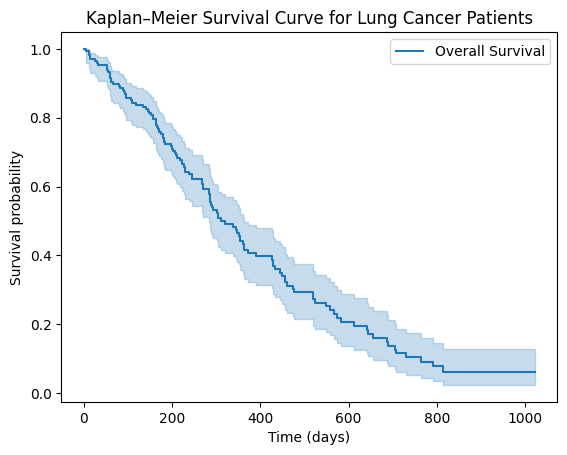

Median survival time: 310.0 days


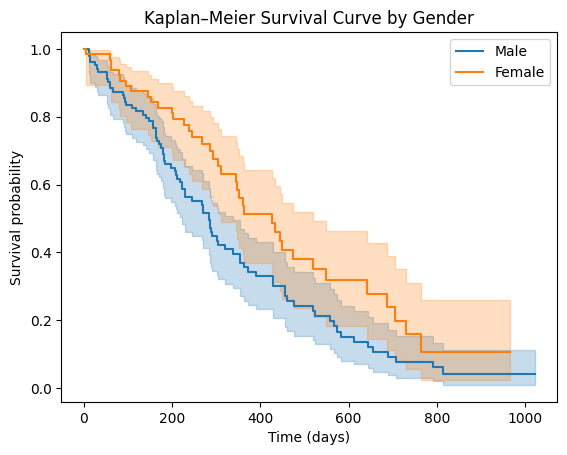

In [ ]:
# =========================================
# STEP 1 — Install lifelines (Run only once in Colab)
# =========================================
!pip install lifelines


# =========================================
# STEP 2 — Import required libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.datasets import load_lung


# =========================================
# STEP 3 — Load the lung cancer dataset
# =========================================
lung_data = load_lung()

# Check data
print(type(lung_data))
lung_data.head()


# =========================================
# STEP 4 — Data cleaning
# =========================================
lung_data = lung_data.dropna()

print("Shape after removing missing values:", lung_data.shape)


# =========================================
# STEP 5 — Fit Kaplan–Meier model (Overall survival)
# =========================================
kmf = KaplanMeierFitter()

kmf.fit(
    durations=lung_data["time"],
    event_observed=lung_data["status"],
    label="Overall Survival"
)

ax = kmf.plot()

ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan–Meier Survival Curve for Lung Cancer Patients")

plt.show()


# =========================================
# STEP 6 — Median survival time
# =========================================
median_survival = kmf.median_survival_time_
print("Median survival time:", median_survival, "days")


# =========================================
# STEP 7 — Survival curve by gender
# 1 = Male, 2 = Female
# =========================================
male = lung_data[lung_data["sex"] == 1]
female = lung_data[lung_data["sex"] == 2]

ax = plt.subplot(111)

kmf.fit(male["time"], male["status"], label="Male")
kmf.plot(ax=ax)

kmf.fit(female["time"], female["status"], label="Female")
kmf.plot(ax=ax)

ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan–Meier Survival Curve by Gender")

plt.show()


In [ ]:
# Male median survival
kmf.fit(male["time"], male["status"], label="Male")
male_median = kmf.median_survival_time_

# Female median survival
kmf.fit(female["time"], female["status"], label="Female")
female_median = kmf.median_survival_time_

print("Median survival time - Male:", male_median, "days")
print("Median survival time - Female:", female_median, "days")

Median survival time - Male: 284.0 days
Median survival time - Female: 426.0 days


log rank test

In [ ]:
from lifelines.statistics import logrank_test

result = logrank_test(
    male["time"], female["time"],
    event_observed_A=male["status"],
    event_observed_B=female["status"]
)

result

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           6.05 0.01      6.16

In [ ]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(lung_data, duration_col="time", event_col="status")

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 167 total observations, 47 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 120
   partial log-likelihood = -491.27
         time fit was run = 2026-02-16 13:50:18 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
inst      -0.03      0.97      0.01           -0.06           -0.00                0.95                1.00
age        0.01      1.01      0.01           -0.01            0.04                0.99                1.04
sex       -0.57      0.57      0.20           -0.96           -0.17                0.38                0.84
ph.ecog    0.91      2.48      0.24            0.44            1.38                1.55                3.96
ph.karno   0.03      1.03      0.01            0.00            0.05                1.00                1.05
pat.karno -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.02      0.98      0.01           -0.03           -0.00                0.97                1.00

           cmp to     z      p  -log2(p)
covariate                               
inst         0.00 -2.31   0.02      5.60
age          0.00  1.07   0.28      1.82
sex          0.00 -2.81 <0.005      7.68
ph.ecog      0.00  3.80 <0.005     12.77
ph.karno     0.00  2.29   0.02      5.49
pat.karno    0.00 -1.34   0.18      2.47
meal.cal     0.00  0.01   0.99      0.01
wt.loss      0.00 -2.11   0.03      4.85
---
Concordance = 0.65
Partial AIC = 998.54
log-likelihood ratio test = 33.70 on 8 df
-log2(p) of ll-ratio test = 14.41

# 🧬 Survival Analysis of Lung Cancer Patients Using Python

## 🔹 Objective

The objective of this analysis is to study the survival experience of lung cancer patients and to identify the clinical factors that significantly influence survival time using:

* Kaplan–Meier survival estimation
* Log-rank test
* Cox proportional hazards model

---

## 🔹 Dataset Description

The dataset consists of **lung cancer patients** with the following information:

* Survival time (in days)
* Censoring status (event observed or not)
* Age of the patient
* Gender
* ECOG performance score
* Karnofsky performance score (physician & patient)
* Calorie intake
* Weight loss
* Institution

After removing missing values, the final dataset contained:

* **Total observations:** 167
* **Number of events (deaths):** 120

---

# 🔹 Methodology

## 1️⃣ Kaplan–Meier Survival Estimation

The Kaplan–Meier method was used to estimate the survival function for the overall sample and separately for males and females.

### 🔸 Median Survival Time

| Group  | Median Survival Time (days) |
| ------ | --------------------------- |
| Male   | **284 days**                |
| Female | **426 days**                |

📌 **Interpretation:**
Female patients have a longer median survival compared to male patients, indicating better prognosis.

---

## 2️⃣ Log-Rank Test

The log-rank test was performed to compare the survival distributions between males and females.

* Test statistic (χ²) = **6.05**
* p-value = **0.01**

### 📌 Interpretation

Since **p < 0.05**, there is a **statistically significant difference in survival** between male and female patients.

This confirms that **gender is an important factor affecting survival**.

---

## 3️⃣ Cox Proportional Hazards Model

The Cox regression model was used to assess the simultaneous effect of multiple covariates on survival.

### 🔸 Overall Model Fit

* Log-likelihood ratio test = **33.70 (df = 8)**
* p-value < **0.001**
* Concordance index = **0.65**

📌 **Interpretation:**

* The model is **statistically significant**
* It has **moderate predictive ability**
* The covariates jointly influence survival

---

# 🔹 Interpretation of Covariates

### ✅ Significant Predictors

#### 1. ECOG Performance Score

* Hazard Ratio (HR) = **2.48**
* p < **0.005**

📌 Interpretation:
For each unit increase in ECOG score, the risk of death increases by **2.48 times**.

➡ Patients with poor functional status have much shorter survival.
This is the **strongest predictor** in the model.

---

#### 2. Gender

* HR = **0.57**
* p < **0.005**

📌 Interpretation:
One gender has **43% lower risk of death** compared to the reference group.

This supports the Kaplan–Meier result that **females have better survival**.

---

#### 3. Physician Karnofsky Score

* HR = **1.03**
* p = **0.02**

📌 Interpretation:
A change in physician-assessed performance status significantly affects survival.

---

#### 4. Weight Loss

* HR = **0.98**
* p = **0.03**

📌 Interpretation:
Weight loss has a small but statistically significant effect on survival.

---

#### 5. Institution

* HR = **0.97**
* p = **0.02**

📌 Interpretation:
Survival differs slightly across institutions.

---

### ❌ Non-Significant Predictors

The following variables were not statistically significant:

* Age (p = 0.28)
* Patient Karnofsky score (p = 0.18)
* Meal calories (p = 0.99)

📌 These variables do not show a meaningful effect on survival in this dataset.

---

# 🔹 Clinical Interpretation

* Patients with **poor ECOG performance status** have a much higher risk of death.
* **Female patients survive longer** than male patients.
* **Physician-assessed performance status** is more reliable than patient-reported status.
* Nutritional and institutional factors show mild influence.
* Age alone is not a strong predictor when other clinical variables are included.

---

# 🔹 Final Conclusion

This study applied Kaplan–Meier estimation, log-rank testing, and Cox proportional hazards modeling to analyze lung cancer survival data.

The Kaplan–Meier analysis showed that females had a higher median survival (426 days) than males (284 days), and the log-rank test confirmed that this difference was statistically significant (p = 0.01).

The Cox regression model identified ECOG performance score as the most important predictor of survival, with patients having poor functional status showing a substantially higher risk of death. Gender, physician Karnofsky score, weight loss, and institution were also significant predictors, while age, patient Karnofsky score, and calorie intake were not significant.

Overall, the model demonstrated moderate predictive accuracy (C-index = 0.65) and provided meaningful clinical insights into factors affecting survival.


